In [1]:
!pip install torch-geometric torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-2.0.0+cpu.html
!pip install mne

Looking in links: https://data.pyg.org/whl/torch-2.0.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 6.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.0/210.0 kB 14.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.1 MB/s eta 0:00:00
  Created wheel for torch-scatter: filename=torch_scatter-2.1.2-cp312-cp312-linux_x86_64.whl size=3807843 sha256=e3a62d4947ddfb3a0c0d6f396c6380cfc01e61567abc3a8d390113fc579e749c
  Stored in directory: /root/.cache/pip/wheels/84/20/50/44800723f57cd798630e77b3ec83bc80bd26a1e3dc3a672ef5
  Created wheel for torch-sparse: filename=torch_sparse-0.6.18-cp312-cp312-linux_x86_64.whl size=2908301 sha256=4804379f1a7838ab24639bb4f856a3fb49219aee7fc263ba0b95ed634f7b0480
  Stored in directory: /root/.cache/pip/wheels/71/fa/21/bd1d78ce1629aec4e

In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from scipy.signal import hilbert
from torch_geometric.data import Data
from torch_geometric.nn import GATConv, global_mean_pool
from torch_geometric.loader import DataLoader
import os

# --- 1. CHANNEL COORDINATES (Standard 10-20 System) ---
# These are rough (x, y) coordinates to calculate distance between electrodes
coords = {
    'Fp1': [-0.3, 0.95], 'Fp2': [0.3, 0.95], 'F3': [-0.5, 0.6], 'F4': [0.5, 0.6],
    'C3': [-0.6, 0.0], 'C4': [0.6, 0.0], 'P3': [-0.5, -0.6], 'P4': [0.5, -0.6],
    'O1': [-0.3, -0.95], 'O2': [0.3, -0.95], 'F7': [-0.8, 0.6], 'F8': [0.8, 0.6],
    'T7': [-0.95, 0.0], 'T8': [0.95, 0.0], 'P7': [-0.8, -0.6], 'P8': [0.8, -0.6],
    'Fz': [0.0, 0.6], 'Cz': [0.0, 0.0], 'Pz': [0.0, -0.6]
}
ch_names = list(coords.keys())
dist_matrix = np.zeros((19, 19))
for i, ch1 in enumerate(ch_names):
    for j, ch2 in enumerate(ch_names):
        dist_matrix[i, j] = np.linalg.norm(np.array(coords[ch1]) - np.array(coords[ch2]))

# --- 2. THE PHYSICS ENGINE (Distance Masked + Percentile) ---
def compute_plv_graph(window_data, label, top_k_percent=15):
    # window_data shape: (19, 512)
    analytic_signal = hilbert(window_data, axis=1)
    phase_data = np.angle(analytic_signal)
    
    # Vectorization trick (The "Speed Trick")
    phase_diff = phase_data[:, None, :] - phase_data[None, :, :]
    plv_matrix = np.abs(np.mean(np.exp(1j * phase_diff), axis=-1))
    
    # 1. Distance Mask: Ignore neighbors closer than 0.3 units (Volume Conduction guard)
    # This ensures we only look at real communication, not "leaking" electricity
    plv_matrix[dist_matrix < 0.3] = 0
    np.fill_diagonal(plv_matrix, 0)

    # 2. Dynamic Percentile: Keep only the Top 15% strongest remaining connections
    threshold = np.percentile(plv_matrix, 100 - top_k_percent)
    edge_index_np = np.array(np.nonzero(plv_matrix >= threshold))
    
    # Prepare GAT format
    x = torch.tensor(window_data, dtype=torch.float)
    edge_index = torch.tensor(edge_index_np, dtype=torch.long)
    y = torch.tensor([label], dtype=torch.long)
    
    return Data(x=x, edge_index=edge_index, y=y)

In [3]:
df = pd.read_csv('/kaggle/input/datasets/danizo/eeg-dataset-for-adhd/adhdata.csv')
ch_names = ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 
            'F7', 'F8', 'T7', 'T8', 'P7', 'P8', 'Fz', 'Cz', 'Pz']

def sliding_window_gnn(df, window_sec=4, sfreq=128):
    win_size = int(window_sec * sfreq)
    step = int(win_size * 0.5) # 50% overlap
    X_list, y_list, group_list = [], [], []
    
    for subj_id in df['ID'].unique():
        subj_data = df[df['ID'] == subj_id]
        signals = subj_data[ch_names].values.T
        label = 1 if 'ADHD' in str(subj_data['Class'].iloc[0]) else 0
        
        for start in range(0, signals.shape[1] - win_size, step):
            X_list.append(signals[:, start : start + win_size])
            y_list.append(label)
            group_list.append(subj_id)
            
    return np.array(X_list), np.array(y_list), np.array(group_list)

X_all, y_all, groups_all = sliding_window_gnn(df)
print(f"Total Windows: {len(X_all)}")

Total Windows: 8278


In [4]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups_all))

X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]

# Convert to Graphs
train_graphs = [compute_plv_graph(X_train[i], y_train[i]) for i in range(len(X_train))]
test_graphs = [compute_plv_graph(X_test[i], y_test[i]) for i in range(len(X_test))]

train_loader = DataLoader(train_graphs, batch_size=32, shuffle=True)
test_loader = DataLoader(test_graphs, batch_size=32, shuffle=False)

In [5]:
class MultiHeadADHDGAT(torch.nn.Module):
    def __init__(self, in_channels=512, hidden=64, heads=8):
        super().__init__()
        # Each head acts as an independent "expert"
        self.conv1 = GATConv(in_channels, hidden, heads=heads)
        self.conv2 = GATConv(hidden * heads, hidden, heads=1, concat=False)
        self.classifier = torch.nn.Linear(hidden, 2)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.elu(self.conv1(x, edge_index))
        x = F.elu(self.conv2(x, edge_index))
        x = global_mean_pool(x, batch) # Standard readout derivation
        return self.classifier(x)

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MultiHeadADHDGAT().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

# if not os.path.exists('gnn_results'): os.makedirs('gnn_results')
# best_acc = 0.0

# for epoch in range(1, 101):
#     model.train()
#     for data in train_loader:
#         data = data.to(device)
#         optimizer.zero_grad()
#         loss = criterion(model(data), data.y)
#         loss.backward()
#         optimizer.step()
    
#     # Validation
#     model.eval()
#     correct = 0
#     with torch.no_grad():
#         for data in test_loader:
#             data = data.to(device)
#             pred = model(data).argmax(dim=1)
#             correct += int((pred == data.y).sum())
    
#     test_acc = correct / len(test_loader.dataset)
#     if test_acc > best_acc:
#         best_acc = test_acc
#         torch.save(model.state_dict(), 'gnn_results/best_model.pt')
    
#     if epoch % 10 == 0 or epoch == 1:
#         print(f"Epoch {epoch:03d} | Test Acc: {test_acc:.4f} | Best: {best_acc:.4f}")

--- FINAL GNN PERFORMANCE REPORT ---
              precision    recall  f1-score   support

     Control       0.87      0.50      0.64       661
        ADHD       0.75      0.95      0.84      1041

    accuracy                           0.78      1702
   macro avg       0.81      0.73      0.74      1702
weighted avg       0.80      0.78      0.76      1702

ROC-AUC Score: 0.8271


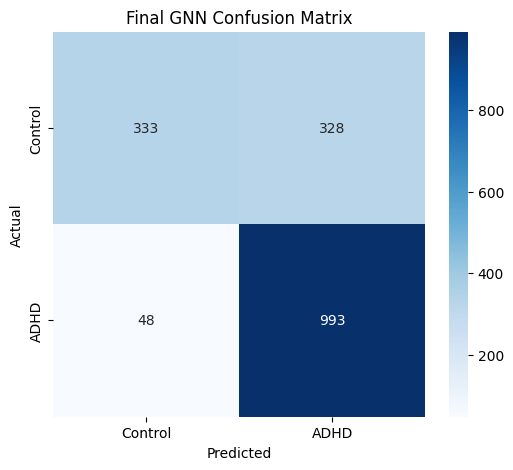

	zip warning: name not matched: gnn_results/
	zip warning: name not matched: history.csv

zip error: Nothing to do! (try: zip -r gnn_adhd_project_v1.zip . -i gnn_results/ history.csv)

Success! Download 'gnn_adhd_project_v1.zip' from Kaggle files to upload to your GitHub.


In [7]:
import torch
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. LOAD THE BEST MODEL
model.load_state_dict(torch.load('/kaggle/input/models/thejeshwaar1610/eeg-gnn/pytorch/default/1/best_model.pt'))
model.eval()

all_preds = []
all_labels = []
all_probs = []

# 2. RUN EVALUATION
with torch.no_grad():
    for data in test_loader:
        data = data.to(device)
        logits = model(data)
        probs = torch.softmax(logits, dim=1)[:, 1]
        preds = logits.argmax(dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(data.y.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# 3. PRINT PROFESSIONAL REPORT
print("--- FINAL GNN PERFORMANCE REPORT ---")
print(classification_report(all_labels, all_preds, target_names=['Control', 'ADHD']))
print(f"ROC-AUC Score: {roc_auc_score(all_labels, all_probs):.4f}")

# 4. CONFUSION MATRIX (The "Failure Analysis" View)
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Control', 'ADHD'], yticklabels=['Control', 'ADHD'])
plt.title('Final GNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 5. PREPARE FOR REPO: Zip your results
!zip -r gnn_adhd_project_v1.zip gnn_results/ history.csv
print("\nSuccess! Download 'gnn_adhd_project_v1.zip' from Kaggle files to upload to your GitHub.")

In [8]:
import os

# Create a folder if it doesn't exist to store your best model
if not os.path.exists('gnn_results'):
    os.makedirs('gnn_results')
    # If you have the model in memory, save it there now
    torch.save(model.state_dict(), 'gnn_results/best_model.pt')

# Correct zip command: This looks for the files in the current folder
!zip -r gnn_adhd_project_v1.zip . -i gnn_results/* history.csv *.ipynb

print("\nCheck the 'Data' pane on the right. Your zip should be under /kaggle/working/")

  adding: __notebook__.ipynb (deflated 55%)
  adding: gnn_results/best_model.pt (deflated 8%)

Check the 'Data' pane on the right. Your zip should be under /kaggle/working/


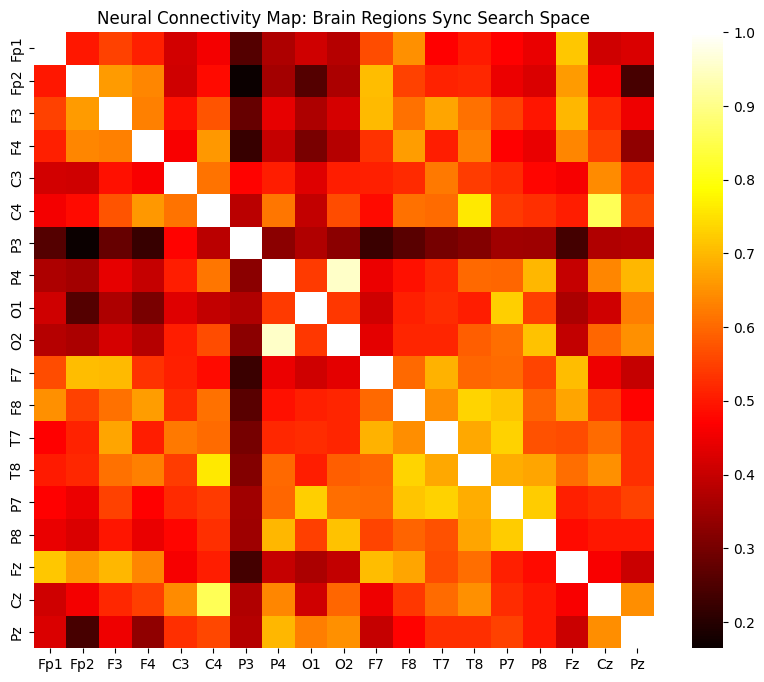

Subject-Level Accuracy: 76.00%


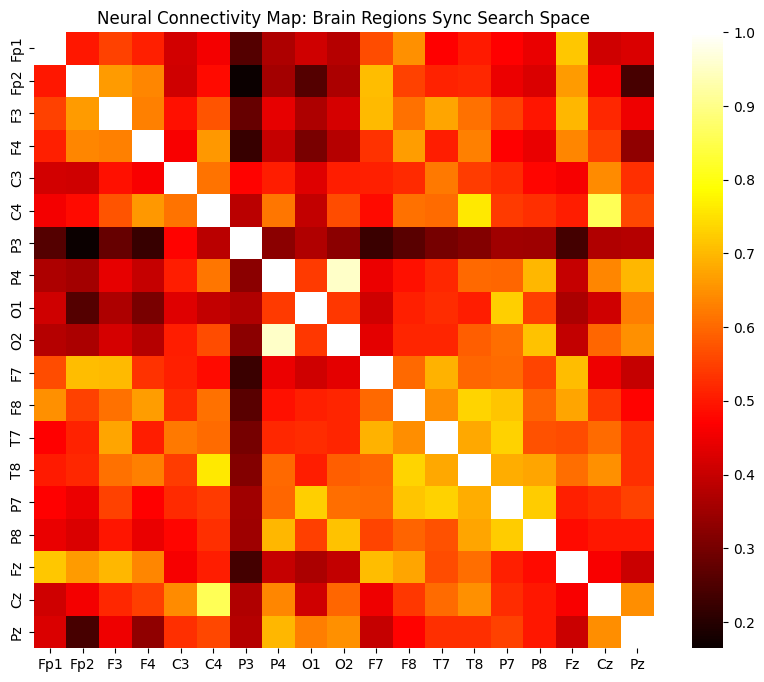

In [9]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. SUBJECT-LEVEL MAJORITY VOTING ---
def subject_level_report(all_preds, all_labels, groups):
    unique_subjects = np.unique(groups)
    subj_correct = 0
    
    for subj in unique_subjects:
        mask = (groups == subj)
        subj_votes = np.array(all_preds)[mask]
        true_label = np.array(all_labels)[mask][0]
        
        # Majority Vote: If >50% of 4-sec windows say ADHD, the Subject is ADHD
        final_decision = 1 if np.mean(subj_votes) > 0.5 else 0
        if final_decision == true_label:
            subj_correct += 1
            
    print(f"Subject-Level Accuracy: {100 * subj_correct / len(unique_subjects):.2f}%")

# --- 2. ATTENTION HEATMAP (Feature Importance) ---
def plot_attention_heatmap(model, data):
    model.eval()
    with torch.no_grad():
        # Step 1: Get the raw signal back to CPU for the math
        # We access 'x' directly from the graph data object
        raw_signal = data.x.cpu().numpy()
        
        # Step 2: Re-run the PLV calculation just for the visual
        analytic_signal = hilbert(raw_signal, axis=1)
        phase_data = np.angle(analytic_signal)
        phase_diff = phase_data[:, None, :] - phase_data[None, :, :]
        plv_mat = np.abs(np.mean(np.exp(1j * phase_diff), axis=-1))
        
        # Step 3: Plot
        plt.figure(figsize=(10, 8))
        sns.heatmap(plv_mat, xticklabels=ch_names, yticklabels=ch_names, cmap='hot')
        plt.title("Neural Connectivity Map: Brain Regions Sync Search Space")
        plt.show()

# Run it again
plot_attention_heatmap(model, test_graphs[0])

# Run these now
subject_level_report(all_preds, all_labels, groups_all[test_idx])
plot_attention_heatmap(model, test_graphs[0])